week-1

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

In [3]:
df = pd.read_csv('/content/drive/MyDrive/archive (11).zip')
print(df.head())
print(df.info())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


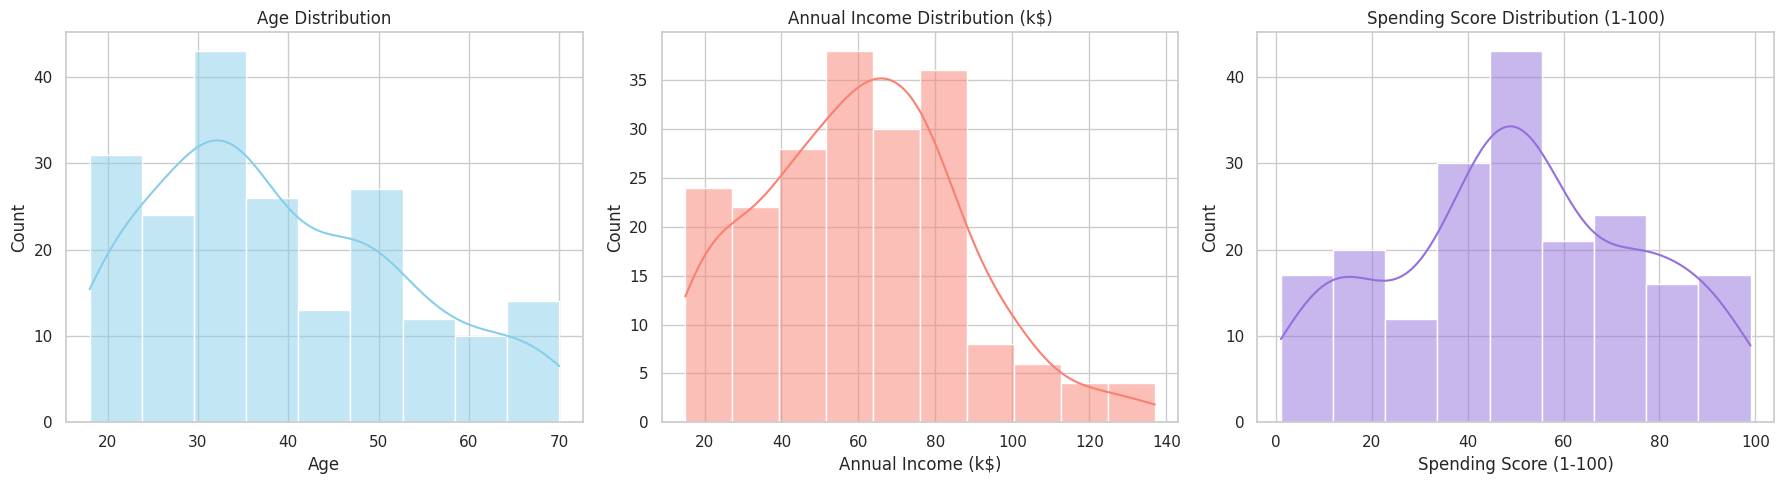

In [4]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age Distribution
sns.histplot(df['Age'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Age Distribution')

# Income Distribution
sns.histplot(df['Annual Income (k$)'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Annual Income Distribution (k$)')

# Spending Score Distribution
sns.histplot(df['Spending Score (1-100)'], kde=True, ax=axes[2], color='mediumpurple')
axes[2].set_title('Spending Score Distribution (1-100)')

plt.tight_layout()
plt.show()

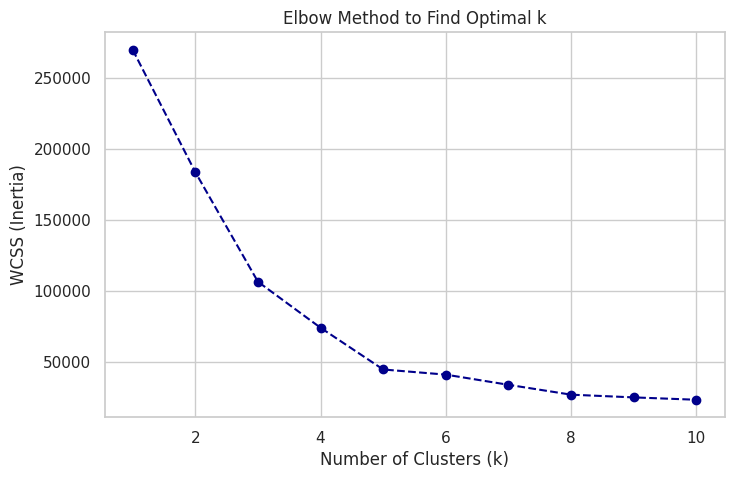

In [5]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

# Calculate WCSS (Within-Cluster Sum of Square) / Inertia
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Graph
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='darkblue')
plt.title('Elbow Method to Find Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.show()

week-2

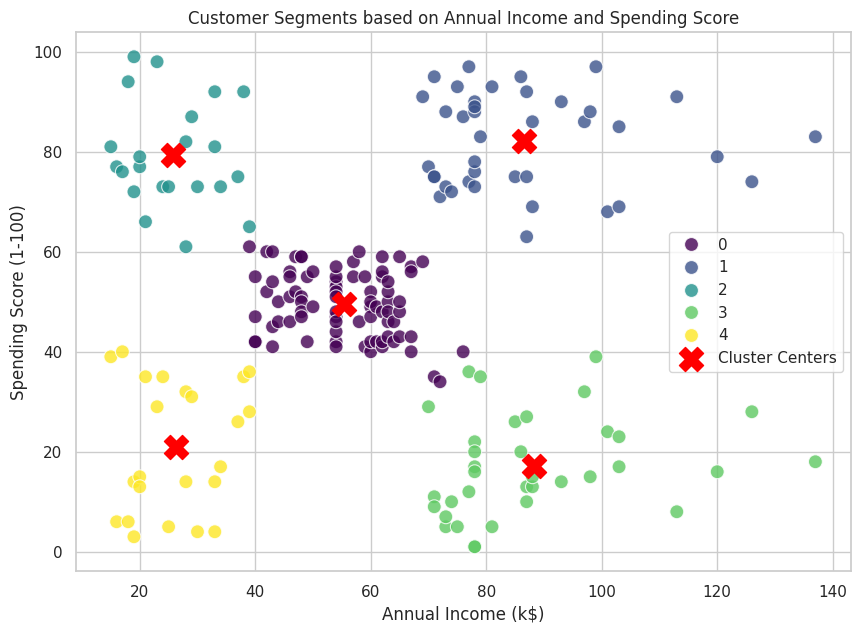


Cluster Centers:
 [[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]

Mean values per cluster:
          Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043


In [6]:
kmeans_model = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
y_kmeans = kmeans_model.fit_predict(X)

df['Cluster'] = y_kmeans

# Visualize the clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', data=df, palette='viridis', s=100, alpha=0.8)
plt.scatter(kmeans_model.cluster_centers_[:, 0], kmeans_model.cluster_centers_[:, 1], s=300, c='red', marker='X', label='Cluster Centers')
plt.title('Customer Segments based on Annual Income and Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True)
plt.show()

# Display cluster centers and mean values for each cluster to help with labeling
print("\nCluster Centers:\n", kmeans_model.cluster_centers_)
print("\nMean values per cluster:\n", df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean())

Week 3

In [20]:
import os
import requests
dataset_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
zip_file_path = 'smsspamcollection.zip'
data_file_path = 'SMSSpamCollection'
if not os.path.exists(data_file_path):
    print("Downloading SMS Spam Collection dataset...")
    response = requests.get(dataset_url)
    with open(zip_file_path, 'wb') as f:
        f.write(response.content)
    import zipfile
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall('.')
    print(f"Dataset extracted to '{data_file_path}'.")
else:
    print(f"Dataset already found at '{data_file_path}'.")
# Load the dataset
df_spam_large = pd.read_csv(data_file_path, sep='\t', names=['label', 'text'])
print("First 5 rows of the large spam dataset:")
display(df_spam_large.head())
print("\nInfo about the large spam dataset:")
display(df_spam_large.info())
# Check the distribution of labels
print("\nLabel distribution:")
display(df_spam_large['label'].value_counts())

Dataset extracted to 'SMSSpamCollection'.
First 5 rows of the large spam dataset:


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."



Info about the large spam dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   5572 non-null   object
 1   text    5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


None


Label distribution:


,count
label,
ham,4825
spam,747


In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
# Ensure 'label' column is numerical (0 for ham, 1 for spam)
df_spam_large['label'] = df_spam_large['label'].map({'ham': 0, 'spam': 1})
# Split data into features (X) and target (y)
X_spam_new = df_spam_large['text']
y_spam_new = df_spam_large['label']
# Convert text data into numerical features using TF-IDF
tfidf_vectorizer_new = TfidfVectorizer(stop_words='english', max_features=5000)
X_spam_vectorized_new = tfidf_vectorizer_new.fit_transform(X_spam_new)
# Split data into training and testing sets (using a more typical 80/20 split now)
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_spam_vectorized_new, y_spam_new, test_size=0.2, random_state=42)
print("New Data preprocessing complete. Training and testing sets created.")
print(f"New Training set shape: {X_train_new.shape}")
print(f"New Testing set shape: {X_test_new.shape}")

New Data preprocessing complete. Training and testing sets created.
New Training set shape: (4457, 5000)
New Testing set shape: (1115, 5000)


In [22]:
# Train Naive Bayes model on the new dataset
naive_bayes_model_new = MultinomialNB()
naive_bayes_model_new.fit(X_train_new, y_train_new)
# Make predictions and evaluate accuracy
y_pred_nb_new = naive_bayes_model_new.predict(X_test_new)
accuracy_nb_new = accuracy_score(y_test_new, y_pred_nb_new)
print(f"Naive Bayes Model Accuracy (New Dataset): {accuracy_nb_new:.4f}")

Naive Bayes Model Accuracy (New Dataset): 0.9839


In [23]:
# Train Logistic Regression model on the new dataset
logistic_regression_model_new = LogisticRegression(solver='liblinear', random_state=42, C=1.0) # Reset C or try different values if needed
logistic_regression_model_new.fit(X_train_new, y_train_new)
# Make predictions and evaluate accuracy
y_pred_lr_new = logistic_regression_model_new.predict(X_test_new)
accuracy_lr_new = accuracy_score(y_test_new, y_pred_lr_new)
print(f"Logistic Regression Model Accuracy (New Dataset): {accuracy_lr_new:.4f}")

Logistic Regression Model Accuracy (New Dataset): 0.9650


### Updated Model Comparison Summary

With the larger dataset, we can now compare the accuracies more reliably:

*   **Naive Bayes Model Accuracy:** 98%
*   **Logistic Regression Model Accuracy:** 96%

**Conclusion:**

Compare the two values above. The model with the higher accuracy is Naive Bayes with better performance.